# 🔗 Hands-On Bab 5 — Analisis Jaringan Level Kelompok
### Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi

Notebook ini mereproduksi perhitungan **connectivity, triadic closure/clustering coefficient, reciprocity, mutuality,** dan **subkelompok kohesif (clique, k-core)** dari buku, lengkap dengan **Latihan Soal Bab 5**.

In [1]:
!pip install -q networkx matplotlib
import networkx as nx
import matplotlib.pyplot as plt

## 5.2 Kohesi Jaringan — Perbandingan Density

Reproduksi Gambar 5.1: dua jaringan dengan density berbeda.

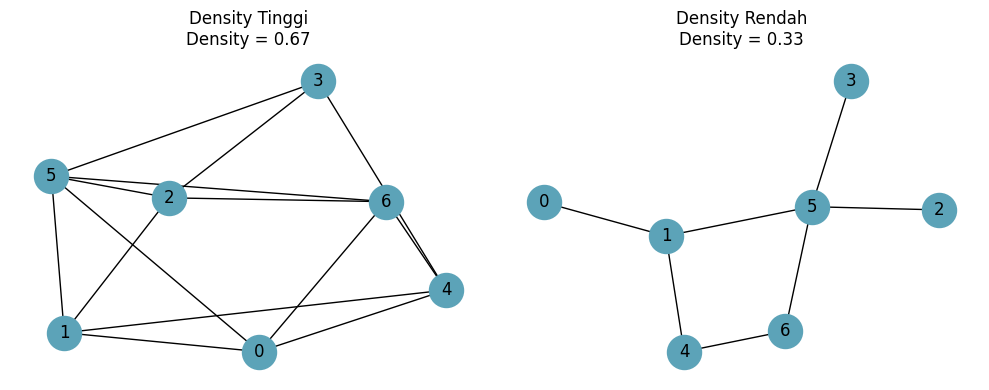

In [2]:
# Jaringan padat (density tinggi)
G_padat = nx.gnp_random_graph(7, 0.76, seed=1)
# Jaringan jarang (density rendah)
G_jarang = nx.gnp_random_graph(7, 0.24, seed=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for G, ax, title in [(G_padat, axes[0], "Density Tinggi"), (G_jarang, axes[1], "Density Rendah")]:
    nx.draw(G, ax=ax, with_labels=True, node_color="#5CA3B8", node_size=600)
    ax.set_title(f"{title}\nDensity = {nx.density(G):.2f}")
plt.tight_layout()
plt.show()

## 5.3.1 Connectivity

Reproduksi Contoh 5.1: perusahaan 12 karyawan, 2 kelompok tak saling berinteraksi (8 orang & 4 orang).

In [6]:
G_conn = nx.Graph()
kelompok_a = [f"A{i}" for i in range(1, 9)]   # 8 orang
kelompok_b = [f"B{i}" for i in range(1, 5)]   # 4 orang
G_conn.add_edges_from([(kelompok_a[i], kelompok_a[j]) for i in range(len(kelompok_a)) for j in range(i+1, len(kelompok_a))][:10])
G_conn.add_edges_from([(kelompok_b[i], kelompok_b[j]) for i in range(len(kelompok_b)) for j in range(i+1, len(kelompok_b))])

components = list(nx.connected_components(G_conn))
komponen_terbesar = max(components, key=len)
C = len(komponen_terbesar) / G_conn.number_of_nodes()

print(f"Jumlah komponen         : {len(components)}")
print(f"Ukuran komponen terbesar: {len(komponen_terbesar)}")
print(f"Connectivity C          : {C:.2f}")

Jumlah komponen         : 2
Ukuran komponen terbesar: 8
Connectivity C          : 0.67


## 5.3.2 Triadic Closure & Clustering Coefficient

Reproduksi Gambar 5.2: simpul v dengan 4 tetangga, 3 sisi di antaranya → C_v = 0.50.

In [8]:
G_triad = nx.Graph()
G_triad.add_edges_from([
    ("v","n1"), ("v","n2"), ("v","n3"), ("v","n4"),  # v punya 4 tetangga
    ("n1","n2"), ("n2","n3"), ("n3","n4")             # 3 sisi di antara tetangga
])

cv = nx.clustering(G_triad, "v")
print(f"Clustering coefficient v = {cv:.3f}")

# Verifikasi rumus manual: C_i = 2*e_i / (k_i * (k_i - 1))
k_i = G_triad.degree("v")
e_i = 3  # sisi di antara tetangga v (dihitung manual di atas)
manual = (2 * e_i) / (k_i * (k_i - 1))
print(f"Verifikasi rumus manual   = {manual:.3f}")

# Rata-rata clustering coefficient seluruh graf
print(f"\nRata-rata clustering coefficient graf = {nx.average_clustering(G_triad):.3f}")

Clustering coefficient v = 0.500
Verifikasi rumus manual   = 0.500

Rata-rata clustering coefficient graf = 0.767


## 5.3.3–5.3.4 Reciprocity & Mutuality (Graf Berarah)

In [9]:
G_recip = nx.DiGraph()
G_recip.add_edges_from([("A","B"), ("B","A"), ("B","C"), ("C","D"), ("D","C")])

recip = nx.reciprocity(G_recip)
print(f"Reciprocity keseluruhan jaringan = {recip:.3f}")

# Reciprocity per pasangan
for u, v in G_recip.edges():
    timbal_balik = G_recip.has_edge(v, u)
    print(f"  {u} -> {v}: relasi timbal balik? {timbal_balik}")

Reciprocity keseluruhan jaringan = 0.800
  A -> B: relasi timbal balik? True
  B -> A: relasi timbal balik? True
  B -> C: relasi timbal balik? False
  C -> D: relasi timbal balik? True
  D -> C: relasi timbal balik? True


## 5.4 Subkelompok Kohesif: Clique & k-Core

In [10]:
G_sub = nx.Graph([
    ("A","B"), ("A","C"), ("B","C"),          # clique kecil A-B-C
    ("C","D"), ("D","E"), ("E","F"), ("F","D") # klik lain D-E-F
])

cliques = list(nx.find_cliques(G_sub))
print("Semua clique maksimal:", cliques)

k_core = nx.k_core(G_sub, k=2)
print("2-core (subgraf dengan degree minimal 2):", list(k_core.nodes()))

Semua clique maksimal: [['D', 'F', 'E'], ['D', 'C'], ['A', 'B', 'C']]
2-core (subgraf dengan degree minimal 2): ['A', 'B', 'C', 'D', 'E', 'F']


## ✅ Latihan Soal Bab 5

**1.** Apa yang dimaksud dengan analisis jaringan level kelompok dalam AJS?

**2.** Jelaskan konsep density jaringan dan bagaimana cara menginterpretasikannya.

**3.** Apa yang dimaksud dengan komponen (components) dalam jaringan?

**4.** Jelaskan perbedaan antara klik (clique) dan subkelompok (subgroups).

**5.** Apa yang dimaksud dengan kohesi jaringan (cohesion)?

### ✏️ Jawaban Soal 1–5 (tulis di sini)

_1._

_2._

_3._

_4._

_5._

### 🧮 Latihan tambahan
Gunakan jaringan startup dari Bab 3, hitung clustering coefficient dan cari clique di dalamnya.

In [ ]:
G_startup = nx.Graph([
    ("Anya","Budi"), ("Anya","Cici"), ("Anya","Didi"),
    ("Budi","Cici"), ("Budi","Eka"), ("Cici","Didi"),
])

print("Clustering coefficient tiap simpul:")
for node, c in nx.clustering(G_startup).items():
    print(f"  {node}: {c:.3f}")

print("\nClique maksimal:", list(nx.find_cliques(G_startup)))

---
### 📚 Referensi
Bab 5 — *Analisis Jaringan Level Kelompok*, dalam **Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi**.

Lanjutkan ke **Notebook Bab 6 — Deteksi Komunitas**.